--- Processing ---
Input: family, medium, high, apology, Reason: 'forgot to wish my mother on her birthday'
----------------------------------------

--- Suggestions Based on Past Effectiveness ---
No similar past examples with ratings.
----------------------------------------
Generating response...
Generation complete.

*** Generated Apology ***
Dear family,

I'm so sorry to have missed your birthday this year. I had so much going on that day, I completely forgot to wish my beloved mother on her special day. I hope you all had a wonderful celebration and that her birthday was as special for you as it was for me.

My heartfelt apologies for not being able to join you for this wonderful occasion. I'll make it up to you by dedicating this
Added to history.
Generating voice...


<ipython-input-7-ad8f9997c0ba>:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat([history_df, new_entry], ignore_index=True); print("Added to history.")


Audio saved: generated_output.mp3



--- Generating iMessage Screenshot ---
iMessage screenshot saved to generated_imessage.png


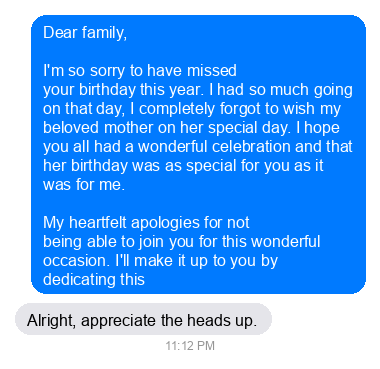


--- Generating Location Log ---
Generating response...
Generation complete.
Generated Location Log: 12:00 PM

Rate effectiveness (1-5), 'fav' to toggle favorite, or ENTER to skip: 2
Feedback recorded (2) for item 4.
History saved: /content/excuse_dataset_mixed.csv

--- Updated History ---

--- Excuse/Apology History ---
  scenario     type                               user_reason                                                                                                                                                                                                                                                                                                                                                                                                     generated_text  effectiveness_rating  is_favorite
0   social  apology        missed a dinner date with the wife  Dear [Wife's Name],\n\nI'm so sorry for missing our dinner date last night. I had a busy work schedule and I was u

In [7]:
# -*- coding: utf-8 -*-
"""
Colab Implementation: Intelligent Excuse Generator - Full Backend Logic
(Using TinyLlama, input() workflow, Image display fix)

Includes: Setup, Data Loading, Fine-tuning (DISABLED), Model Loading,
          User Input (via input()), Generation, Proof Generation (TTS, iMessage, Location, Emergency),
          History, Favorites, Simulated Ranking.
"""
# section 1
!pip install -q -U transformers accelerate bitsandbytes pandas gTTS Pillow datasets ipywidgets trl peft

import torch
import pandas as pd
import numpy as np
import random
import os
import json
from datetime import datetime
import textwrap # For better text wrapping in images

# Hugging Face Libraries
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    logging as hf_logging
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer

# Proof Generation & Utilities
from google.colab import drive, files # For data loading/saving
from gtts import gTTS # For Text-to-Speech
from PIL import Image, ImageDraw, ImageFont # <<< Pillow Image <<<
# --- CORRECTED IMAGE DISPLAY IMPORT ---
from IPython.display import Audio, display, clear_output
from IPython.display import Image as IPythonImage # <<< Use alias for IPython display <<<
# --- END CORRECTION ---
import ipywidgets as widgets # Still needed for Button/Output in pure input version if desired (though not used in run_excuse_generator)


# Suppress excessive warnings from Hugging Face libraries if desired
hf_logging.set_verbosity_warning()

# Check for GPU
if torch.cuda.is_available():
    print("GPU detected:")
    !nvidia-smi -L
    gpu_available = True
else:
    print("---------------------------------------------------------------------------")
    print("WARNING: No GPU detected. Model loading will happen on CPU (VERY SLOW).")
    print("---------------------------------------------------------------------------")
    gpu_available = False

# --- Constants & Configuration ---
BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" # Using TinyLlama
FINE_TUNED_ADAPTER_DIR = "tinyllama-excuse-generator-adapter"

# File Paths (Ensure these files are uploaded or paths are correct)
# Use the names of your cleaned CSV files
EXCUSE_CSV_PATH = '/content/excuse_dataset_cleaned_FIXED.csv'
APOLOGY_CSV_PATH = '/content/apology_dataset_template_FIXED.csv'
HISTORY_CSV_PATH = '/content/excuse_dataset_mixed.csv'

# Proof Generation Paths
GENERATED_AUDIO_PATH = 'generated_output.mp3'
GENERATED_IMSG_PATH = 'generated_imessage.png'
GENERATED_EMERGENCY_SMS_PATH = 'generated_emergency_sms.png'
# IMPORTANT: Upload a TrueType Font (.ttf) file and update FONT_PATH
UPLOADED_FONT_NAME = "arial.ttf" # Example: Replace if you uploaded a different font
FONT_PATH = UPLOADED_FONT_NAME
FONT_SIZE_MSG = 16
FONT_SIZE_INFO = 12

# Predefined Generic Replies
GENERIC_REPLIES = [
    "Okay, thanks for letting me know.", "Understood. Hope everything is alright.",
    "Got it. Please keep me updated if anything changes.",
    "Alright, appreciate the heads up.", "Okay, take care.", "Noted.", "Fine.",
    "Received.", "Acknowledged."
]

# --- Global Variables ---
model = None
tokenizer = None
is_model_fine_tuned = False
# Ensure history DataFrame includes 'user_reason' column
history_df = pd.DataFrame(columns=['timestamp', 'scenario', 'urgency', 'believability', 'type', 'user_reason', 'generated_text', 'effectiveness_rating', 'is_favorite'])
load_on_cpu = not gpu_available # Determine CPU loading early

from huggingface_hub import notebook_login
try:
    notebook_login()
except Exception as e:
    print(f"notebook_login() failed, trying command line login: {e}")
    print("Please paste your token below when prompted.")
    !huggingface-cli login



# section 2
# --- Load dataframes ---
try:
    excuse_df = pd.read_csv(EXCUSE_CSV_PATH)
    apology_df = pd.read_csv(APOLOGY_CSV_PATH)
    # Basic Cleaning
    # Ensure the correct column name ('excuse') is used for dropna before renaming
    excuse_df.dropna(subset=['scenario', 'urgency', 'believability', 'excuse'], inplace=True)
    apology_df.dropna(subset=['scenario', 'urgency', 'believability', 'apology'], inplace=True)
    excuse_df.columns = ['scenario', 'urgency', 'believability', 'text'] # Standardize column name
    excuse_df['type'] = 'excuse'
    apology_df.columns = ['scenario', 'urgency', 'believability', 'text'] # Standardize column name
    apology_df['type'] = 'apology'
    # Combine datasets
    combined_df = pd.concat([excuse_df, apology_df], ignore_index=True)
    combined_df = combined_df.astype(str)
    print(f"Datasets loaded and combined: {len(combined_df)} total entries.")
    # Check font
    if not os.path.exists(FONT_PATH): print(f"WARNING: Font '{FONT_PATH}' not found! Screenshots may fail/look basic.")
except FileNotFoundError as e:
    print(f"ERROR: File not found: {e}. Upload CSVs/Font or fix paths."); raise SystemExit("Data files missing.")
except KeyError as e:
    print(f"ERROR: Missing expected column header in CSV: {e}. Check CSV headers match code expectations ('excuse', 'apology')."); raise SystemExit("CSV Header Error.")
except Exception as e:
    print(f"An error occurred loading/preparing datasets: {e}"); raise SystemExit("Dataset loading error.")

# --- Load History ---
if os.path.exists(HISTORY_CSV_PATH):
    try:
        history_df = pd.read_csv(HISTORY_CSV_PATH)
        if 'user_reason' not in history_df.columns: history_df['user_reason'] = None
        history_df['effectiveness_rating'] = pd.to_numeric(history_df['effectiveness_rating'], errors='coerce')
        history_df['is_favorite'] = history_df['is_favorite'].astype(bool)
        print(f"Loaded existing history from '{HISTORY_CSV_PATH}' ({len(history_df)} entries).")
    except Exception as e:
        print(f"Warning: Could not load history: {e}. Starting fresh.")
        history_df = pd.DataFrame(columns=['timestamp', 'scenario', 'urgency', 'believability', 'type', 'user_reason', 'generated_text', 'effectiveness_rating', 'is_favorite'])
else:
    print(f"No history file found at '{HISTORY_CSV_PATH}'. Starting fresh.")
    history_df = pd.DataFrame(columns=['timestamp', 'scenario', 'urgency', 'believability', 'type', 'user_reason', 'generated_text', 'effectiveness_rating', 'is_favorite'])

#secion 3
run_fine_tuning = False

# --- Fine-tuning Setup ---
# (Code for fine-tuning setup remains here but won't run if run_fine_tuning=False)
def create_finetuning_prompt(row):
    system_message = "You are an intelligent assistant that generates context-aware excuses and apologies."
    instruction = f"Generate a single, concise, {row['believability']} believability, {row['urgency']} urgency {row['type']} for a '{row['scenario']}' scenario."
    response = row['text']
    return f"<|system|>\n{system_message}</s>\n<|user|>\n{instruction}</s>\n<|assistant|>\n{response}</s>"

if run_fine_tuning and gpu_available:
    print("Preparing data for fine-tuning...")
    try: combined_df['formatted_prompt'] = combined_df.apply(create_finetuning_prompt, axis=1)
    except KeyError as e: print(f"ERROR: Missing column: {e}"); raise SystemExit("Data formatting error.")
    hf_dataset = Dataset.from_pandas(combined_df[['formatted_prompt']])
    train_dataset = hf_dataset
    print(f"Dataset prepared with {len(train_dataset)} examples.")
    # Configs
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False)
    lora_config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM", target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'])
    # Load Model FT
    print(f"Loading base model ({BASE_MODEL_ID}) for fine-tuning...")
    model_ft = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto", trust_remote_code=True)
    model_ft.config.use_cache = False; model_ft.config.pretraining_tp = 1
    tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
    if tokenizer_ft.pad_token is None: tokenizer_ft.pad_token = tokenizer_ft.eos_token
    tokenizer_ft.padding_side = "right"
    # PEFT
    print("Applying PEFT/LoRA adapter...")
    model_ft = prepare_model_for_kbit_training(model_ft); model_ft = get_peft_model(model_ft, lora_config); model_ft.print_trainable_parameters()
    # Training Args
    training_arguments = TrainingArguments(output_dir="./results_tinyllama", num_train_epochs=1, per_device_train_batch_size=1, gradient_accumulation_steps=4, optim="paged_adamw_32bit", save_steps=100, logging_steps=10, learning_rate=2e-4, weight_decay=0.001, fp16=True, bf16=False, max_grad_norm=0.3, max_steps=-1, warmup_ratio=0.03, group_by_length=True, lr_scheduler_type="cosine", report_to="none")
    # Trainer
    trainer = SFTTrainer(model=model_ft, train_dataset=train_dataset, peft_config=lora_config, max_seq_length=256, tokenizer=tokenizer_ft, args=training_arguments, packing=False)
    # Train
    print("Starting fine-tuning..."); train_result = trainer.train(); print("Fine-tuning finished.")
    # Save
    print(f"Saving adapter to '{FINE_TUNED_ADAPTER_DIR}'..."); trainer.model.save_pretrained(FINE_TUNED_ADAPTER_DIR); tokenizer_ft.save_pretrained(FINE_TUNED_ADAPTER_DIR); print("Adapter saved.")
    is_model_fine_tuned = True
    # Cleanup
    del model_ft, trainer; torch.cuda.empty_cache(); print("Cleaned up FT model.")
elif run_fine_tuning and not gpu_available: print("Cannot run fine-tuning without a GPU.")
else: print("Skipping fine-tuning."); is_model_fine_tuned = os.path.isdir(FINE_TUNED_ADAPTER_DIR) # Check if adapter exists

#section 4

# --- Load Base Model & Adapter ---
if not load_on_cpu: # Try GPU first
    bnb_config_inference = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False)
    print(f"Loading base model for GPU inference: {BASE_MODEL_ID}...")
    try:
        model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=bnb_config_inference, device_map="auto", trust_remote_code=True)
        print("Base model loaded onto GPU (quantized).")
    except Exception as e: print(f"GPU load failed: {e}. Falling back to CPU."); load_on_cpu = True; model = None
else: print("Proceeding directly to load model onto CPU."); load_on_cpu = True

if load_on_cpu:
     print(f"Loading base model onto CPU: {BASE_MODEL_ID}..."); is_model_fine_tuned = False # Can't easily use adapter on CPU
     try: model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, trust_remote_code=True); print("Base model loaded onto CPU.")
     except Exception as e: print(f"ERROR loading model onto CPU: {e}"); model = None

# --- Load Tokenizer & Merge Adapter (if applicable and on GPU) ---
if model:
    try:
        tokenizer_path = BASE_MODEL_ID
        if is_model_fine_tuned and not load_on_cpu: # Only load adapter if fine-tuned AND on GPU
            if os.path.isdir(FINE_TUNED_ADAPTER_DIR):
                 try:
                     print(f"Loading fine-tuned adapter from {FINE_TUNED_ADAPTER_DIR}...")
                     model = PeftModel.from_pretrained(model, FINE_TUNED_ADAPTER_DIR)
                     tokenizer_path = FINE_TUNED_ADAPTER_DIR
                     print("Adapter loaded.")
                 except Exception as e: print(f"WARN: Failed loading adapter: {e}. Using base."); is_model_fine_tuned = False
            else: print(f"WARN: Adapter dir '{FINE_TUNED_ADAPTER_DIR}' not found. Using base."); is_model_fine_tuned = False
        elif is_model_fine_tuned and load_on_cpu: print("WARN: Skipping adapter load on CPU model.")

        print(f"Loading tokenizer from: {tokenizer_path}...")
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_path, trust_remote_code=True)
        if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left" if not load_on_cpu else "right" # Left for GPU generation
        print("Tokenizer loaded.")
    except Exception as e: print(f"ERROR loading tokenizer: {e}"); tokenizer = None
else: print("Model failed to load, skipping tokenizer."); tokenizer = None

#section 5

# --- 5a. Core Generation Function ---
def generate_response(prompt_instruction):
    if not model or not tokenizer: return "Error: Model not loaded."
    system_message = "You are an intelligent assistant that generates context-aware excuses and apologies."
    full_prompt = f"<|system|>\n{system_message}</s>\n<|user|>\n{prompt_instruction}</s>\n<|assistant|>\n"
    if not load_on_cpu: inputs = tokenizer(full_prompt, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)
    else: inputs = tokenizer(full_prompt, return_tensors="pt", padding=True, truncation=True, max_length=512)
    print("Generating response...")
    try:
        with torch.no_grad(): outputs = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.7, top_p=0.9, pad_token_id=tokenizer.eos_token_id, eos_token_id=tokenizer.eos_token_id)
        input_length = inputs['input_ids'].shape[1]; generated_ids = outputs[0][input_length:]
        response_text = tokenizer.decode(generated_ids, skip_special_tokens=True).split('<|user|>')[0].split('<|assistant|>')[0].strip()
        response_text = response_text.replace("Dear [Name],", "").strip().replace("I hope this letter finds you", "").strip()
        if response_text.startswith("I am writing to inform you"): response_text = response_text[len("I am writing to inform you"):].strip()
        print("Generation complete.")
        return response_text
    except Exception as e: print(f"Error during generation: {e}"); import traceback; traceback.print_exc(); return f"Error: Generation failed - {e}"

# --- 5b. Text-to-Speech ---
def generate_voice_output(text, filename=GENERATED_AUDIO_PATH):
    try: print(f"Generating voice..."); tts = gTTS(text=text, lang='en'); tts.save(filename); print(f"Audio saved: {filename}"); return filename
    except Exception as e: print(f"Voice Error: {e}"); return None

# --- 5c. iMessage Screenshot Generation ---
import textwrap # Ensure textwrap is imported

def generate_imessage_screenshot(excuse_text, reply_text, filename=GENERATED_IMSG_PATH):
    """Generates a fake iMessage screenshot using Pillow - Revised using multiline methods."""
    print("\n--- Generating iMessage Screenshot ---")
    try:
        # --- Load font ---
        try:
            font_msg = ImageFont.truetype(FONT_PATH, FONT_SIZE_MSG)
            font_info = ImageFont.truetype(FONT_PATH, FONT_SIZE_INFO)
        except IOError:
            print(f"WARNING: Font '{FONT_PATH}' not found. Using default PIL font.")
            font_msg = ImageFont.load_default()
            font_info = ImageFont.load_default()

        # --- Parameters ---
        padding = 15         # Outer padding of the image
        bubble_padding_h = 12 # Horizontal padding inside bubble
        bubble_padding_v = 8  # Vertical padding inside bubble
        bubble_radius = 15    # Corner radius for bubbles
        img_width = 380       # Width of the screenshot image
        max_bubble_width_ratio = 0.75 # Max width bubble takes relative to image
        inter_bubble_space = 10 # Vertical space between bubbles
        timestamp_space = 20  # Vertical space allocated for timestamp
        line_spacing = 4      # Extra pixels between lines of text

        max_text_width = img_width * max_bubble_width_ratio

        # --- Prepare Text (Wrapping) ---
        # Estimate wrap width based on font size (adjust multiplier if needed)
        avg_char_width = font_msg.getlength("A") if hasattr(font_msg, "getlength") else 8
        wrap_width_chars = int(max_text_width / (avg_char_width * 0.6)) # Heuristic
        excuse_wrapped = "\n".join(textwrap.wrap(excuse_text, width=wrap_width_chars, replace_whitespace=False))
        reply_wrapped = "\n".join(textwrap.wrap(reply_text, width=wrap_width_chars, replace_whitespace=False))

        # --- Calculate Text Sizes using multiline_textbbox ---
        # Create a dummy draw object to measure text accurately with line spacing
        dummy_img = Image.new('RGB', (1, 1))
        dummy_draw = ImageDraw.Draw(dummy_img)

        try:
            excuse_bbox = dummy_draw.multiline_textbbox((0, 0), excuse_wrapped, font=font_msg, spacing=line_spacing)
            excuse_text_w = excuse_bbox[2] - excuse_bbox[0]
            excuse_text_h = excuse_bbox[3] - excuse_bbox[1]

            reply_bbox = dummy_draw.multiline_textbbox((0, 0), reply_wrapped, font=font_msg, spacing=line_spacing)
            reply_text_w = reply_bbox[2] - reply_bbox[0]
            reply_text_h = reply_bbox[3] - reply_bbox[1]
        except AttributeError:
             # Fallback for older Pillow versions (less accurate spacing)
             print("Warning: Using older Pillow textsize fallback, spacing might be less accurate.")
             excuse_text_w, excuse_text_h = dummy_draw.multiline_textsize(excuse_wrapped, font=font_msg, spacing=line_spacing)
             reply_text_w, reply_text_h = dummy_draw.multiline_textsize(reply_wrapped, font=font_msg, spacing=line_spacing)

        # --- Calculate Bubble Sizes ---
        excuse_bubble_w = min(excuse_text_w + 2 * bubble_padding_h, img_width - 2 * padding)
        excuse_bubble_h = excuse_text_h + 2 * bubble_padding_v
        reply_bubble_w = min(reply_text_w + 2 * bubble_padding_h, img_width - 2 * padding)
        reply_bubble_h = reply_text_h + 2 * bubble_padding_v

        # --- Calculate Image Height ---
        img_height = padding + excuse_bubble_h + inter_bubble_space + reply_bubble_h + timestamp_space + padding

        # --- Create Image and Draw ---
        img = Image.new('RGB', (img_width, int(img_height)), color=(255, 255, 255))
        draw = ImageDraw.Draw(img)

        # Bubble colors
        blue_bubble_color = (0, 122, 255); grey_bubble_color = (229, 229, 234)
        text_color_blue = (255, 255, 255); text_color_grey = (0, 0, 0)
        time_color = (150, 150, 150)

        # --- Draw Excuse Bubble (Blue, Right Aligned) ---
        excuse_bubble_x = img_width - padding - excuse_bubble_w
        excuse_bubble_y = padding
        draw.rounded_rectangle(
            (excuse_bubble_x, excuse_bubble_y, excuse_bubble_x + excuse_bubble_w, excuse_bubble_y + excuse_bubble_h),
            radius=bubble_radius, fill=blue_bubble_color
        )
        # Draw text using multiline_text
        excuse_text_draw_x = excuse_bubble_x + bubble_padding_h
        excuse_text_draw_y = excuse_bubble_y + bubble_padding_v
        draw.multiline_text(
            (excuse_text_draw_x, excuse_text_draw_y),
            excuse_wrapped,
            font=font_msg,
            fill=text_color_blue,
            align="left", # Align lines left within the text block
            spacing=line_spacing
        )

        # --- Draw Reply Bubble (Grey, Left Aligned) ---
        reply_bubble_x = padding
        reply_bubble_y = excuse_bubble_y + excuse_bubble_h + inter_bubble_space
        draw.rounded_rectangle(
            (reply_bubble_x, reply_bubble_y, reply_bubble_x + reply_bubble_w, reply_bubble_y + reply_bubble_h),
            radius=bubble_radius, fill=grey_bubble_color
        )
        # Draw text using multiline_text
        reply_text_draw_x = reply_bubble_x + bubble_padding_h
        reply_text_draw_y = reply_bubble_y + bubble_padding_v
        draw.multiline_text(
            (reply_text_draw_x, reply_text_draw_y),
            reply_wrapped,
            font=font_msg,
            fill=text_color_grey,
            align="left",
            spacing=line_spacing
        )

        # --- Draw Timestamp ---
        timestamp_text = datetime.now().strftime("%I:%M %p")
        # Use textbbox for accurate centering
        try:
            ts_bbox = font_info.getbbox(timestamp_text)
            ts_width = ts_bbox[2] - ts_bbox[0]
        except AttributeError:
            ts_width, _ = font_info.getsize(timestamp_text)

        ts_x = (img_width - ts_width) / 2
        ts_y = reply_bubble_y + reply_bubble_h + (timestamp_space / 4) # Position below last bubble
        draw.text((ts_x, ts_y), timestamp_text, font=font_info, fill=time_color)

        # --- Save and return ---
        img.save(filename)
        print(f"iMessage screenshot saved to {filename}")
        return filename

    except Exception as e:
        print(f"Error generating iMessage screenshot: {e}")
        import traceback; traceback.print_exc()
        return None
# --- 5d. Location Log Generation ---
def generate_location_log(excuse_text, user_reason=""):
    print("\n--- Generating Location Log ---")
    if not model or not tokenizer: return "Error: Model not loaded."
    context_hint = f"User reason: '{user_reason}'. " if user_reason else ""
    log_prompt = (f"{context_hint}Generate ONLY a single fake location log entry like this: "
                  f"HH:MM AM/PM: Location - [General Area]. Status: [Brief Status].")
    location_log_entry = generate_response(log_prompt).split('\n')[0]
    print(f"Generated Location Log: {location_log_entry}"); return location_log_entry

# --- 5e. Emergency SMS Screenshot ---
def generate_emergency_sms_screenshot(emergency_text, sender="Mom", filename=GENERATED_EMERGENCY_SMS_PATH):
    print("\n--- Generating Emergency SMS Screenshot ---")
    # (Code is very similar to iMessage, reusing helper)
    try:
        try: font_msg = ImageFont.truetype(FONT_PATH, FONT_SIZE_MSG); font_info = ImageFont.truetype(FONT_PATH, FONT_SIZE_INFO)
        except IOError: font_msg = ImageFont.load_default(); font_info = ImageFont.load_default()
        padding = 15; bubble_padding_h = 12; bubble_padding_v = 8; bubble_radius = 15; img_width = 380; max_text_width = img_width * 0.70; timestamp_space = 25
        # Use same helper as iMessage screenshot
        sms_wrapped, sms_size = get_wrapped_text_and_size(emergency_text, font_msg, max_text_width)
        sms_bubble_w = min(sms_size[0] + 2 * bubble_padding_h, img_width - 2 * padding); sms_bubble_h = sms_size[1] + 2 * bubble_padding_v
        img_height = padding + timestamp_space + sms_bubble_h + padding
        # <<< Using PIL Image explicitly >>>
        img = Image.new('RGB', (img_width, int(img_height)), color=(255, 255, 255))
        draw = ImageDraw.Draw(img); grey_bubble_color = (229, 229, 234); text_color_grey = (0, 0, 0); info_color = (100, 100, 100)
        info_text = f"{sender} - {datetime.now().strftime('%I:%M %p')}"
        try: info_bbox = font_info.getbbox(info_text); info_width = info_bbox[2] - info_bbox[0]
        except AttributeError: info_width, _ = font_info.getsize(info_text)
        info_x = (img_width - info_width) / 2; info_y = padding
        draw.text((info_x, info_y), info_text, font=font_info, fill=info_color)
        sms_bubble_x = padding; sms_bubble_y = info_y + timestamp_space - 5
        draw.rounded_rectangle((sms_bubble_x, sms_bubble_y, sms_bubble_x + sms_bubble_w, sms_bubble_y + sms_bubble_h), radius=bubble_radius, fill=grey_bubble_color)
        draw.text((sms_bubble_x + bubble_padding_h, sms_bubble_y + bubble_padding_v), sms_wrapped, font=font_msg, fill=text_color_grey, anchor="lt")
        img.save(filename); print(f"SMS saved: {filename}"); return filename
    except Exception as e: print(f"SMS Error: {e}"); return None

# --- 5f. Fake Emergency Trigger ---
def trigger_fake_emergency():
    print("\n--- Triggering Fake Emergency Simulation ---")
    if model and tokenizer:
        emergency_msg = generate_response("Generate ONLY short, urgent fake emergency text message content (e.g., 'Urgent! Call ASAP.')")
        if emergency_msg and "Error" not in emergency_msg and len(emergency_msg) < 100:
            img_file = generate_emergency_sms_screenshot(emergency_msg)
            if img_file: display(IPythonImage(filename=img_file)) # <<< Use Alias
        else: print(f"Failed generating suitable emergency msg. Got: {emergency_msg}")
    else: print("Model not loaded.")

# --- 5g. History & Favorites Management ---
def add_to_history(scenario, urgency, believability, gen_type, reason, text, rating=None, favorite=False):
    global history_df
    new_entry = pd.DataFrame([{'timestamp': datetime.now(), 'scenario': scenario, 'urgency': urgency, 'believability': believability, 'type': gen_type, 'user_reason': reason, 'generated_text': text, 'effectiveness_rating': rating, 'is_favorite': favorite}])
    history_df = pd.concat([history_df, new_entry], ignore_index=True); print("Added to history.")
def save_history():
    try: history_df.to_csv(HISTORY_CSV_PATH, index=False); print(f"History saved: {HISTORY_CSV_PATH}")
    except Exception as e: print(f"Save History Error: {e}")
def toggle_favorite(index):
    global history_df
    if not (0 <= index < len(history_df)): print("Invalid history index."); return
    history_df.loc[index, 'is_favorite'] = not history_df.loc[index, 'is_favorite']
    status = "marked favorite" if history_df.loc[index, 'is_favorite'] else "unmarked favorite"
    print(f"Item {index} {status}."); save_history()
def record_feedback(index, rating):
    global history_df
    if not (0 <= index < len(history_df)): print("Invalid history index."); return False
    try: rating_val = int(rating); assert 1 <= rating_val <= 5; history_df.loc[index, 'effectiveness_rating'] = rating_val; print(f"Feedback recorded ({rating_val}) for item {index}."); save_history(); return True
    except: print(f"Invalid rating '{rating}'. Must be 1-5."); return False
def display_history(show_favorites_only=False):
    print("\n--- Excuse/Apology History ---")
    df_to_show = history_df[history_df['is_favorite']] if show_favorites_only else history_df
    if df_to_show.empty: print(f"No {'favorites' if show_favorites_only else 'history'} found."); return
    if show_favorites_only: print("(Showing Favorites Only)")
    display_cols = ['scenario', 'type', 'user_reason', 'generated_text', 'effectiveness_rating', 'is_favorite']
    with pd.option_context('display.max_colwidth', None): print(df_to_show[display_cols].to_string(index=True))

# --- 5h. Smart Ranking Logic (Basic) ---
def get_ranked_suggestion(scenario, urgency, believability, gen_type, reason="", top_n=3):
    print("\n--- Suggestions Based on Past Effectiveness ---")
    if history_df.empty or history_df['effectiveness_rating'].isna().all(): print("No effectiveness data available."); return []
    filt_df = history_df[(history_df['scenario'] == scenario) & (history_df['urgency'] == urgency) & (history_df['believability'] == believability) & (history_df['type'] == gen_type) & (history_df['effectiveness_rating'].notna())].copy()
    if filt_df.empty: print("No similar past examples with ratings."); return []
    ranked = filt_df.sort_values(by=['effectiveness_rating', 'timestamp'], ascending=[False, False])
    suggestions = ranked['generated_text'].unique().tolist()[:top_n]
    print(f"Top {len(suggestions)} suggestions:")
    for i, sug in enumerate(suggestions): print(f"{i+1}. (Rating: {ranked[ranked['generated_text'] == sug]['effectiveness_rating'].iloc[0]:.0f}) {sug}")
    return suggestions

#section 6
def run_excuse_generator():
    """Runs one full cycle of input -> generation -> proofs -> feedback."""
    clear_output(wait=True) # Clear previous run's output before asking for input
    print("--- Starting New Generation ---")
    if not model or not tokenizer:
        print("ERROR: Model/tokenizer not loaded. Run Section 4 first.")
        return

    # 1) Gather inputs
    try:
        scenario = input("Scenario (work/school/family/social): ").strip().lower()
        urgency  = input("Urgency (low/medium/high): ").strip().lower()
        believ   = input("Believability (low/medium/high): ").strip().lower()
        gen_type = input("Type (excuse/apology): ").strip().lower()
        reason   = input("Specific reason (e.g. missed meeting): ").strip()
    except EOFError:
        print("\nInput interrupted. Aborting.")
        return

    # Basic validation
    valid_options = {
        "scenario": ["work","school","family","social"],
        "urgency":  ["low","medium","high"],
        "believability": ["low","medium","high"],
        "type":     ["excuse","apology"]
    }
    inputs_provided = {"scenario": scenario, "urgency": urgency, "believability": believ, "type": gen_type}
    for name, val in inputs_provided.items():
        if val not in valid_options[name]:
            print(f"\nERROR: Invalid {name!r} '{val}'. Must be one of {valid_options[name]}.")
            return
    if not reason:
        print("\nERROR: Reason cannot be empty.")
        return

    # Clear inputs area and show processing message
    clear_output(wait=True)
    print("--- Processing ---")
    print(f"Input: {scenario}, {urgency}, {believ}, {gen_type}, Reason: '{reason}'")
    print("-" * 40)

    # 2) Show ranked suggestions from history
    get_ranked_suggestion(scenario, urgency, believ, gen_type, reason=reason)
    print("-" * 40)

    # 3) Generate a new excuse/apology
    prompt = (
        f"Generate a short, informal text message style {gen_type} suitable for a '{scenario}' scenario. "
        f"The specific reason is: '{reason}'. Make it sound {believ} believability and {urgency} urgency. "
        f"Keep it concise. Do NOT use formal greetings like 'Dear'."
    )
    gen_text = generate_response(prompt) # Uses helper defined in Section 5
    if not gen_text or gen_text.startswith("Error"):
        print("Generation failed:", gen_text); return

    print(f"\n*** Generated {gen_type.capitalize()} ***")
    print(gen_text)
    idx = len(history_df)
    add_to_history(scenario, urgency, believ, gen_type, reason, gen_text) # Uses helper

    # 4) Proofs: play audio, show screenshot, print location log
    audio_path = generate_voice_output(gen_text) # Uses helper
    if audio_path: display(Audio(audio_path))

    reply = random.choice(GENERIC_REPLIES)
    img_path = generate_imessage_screenshot(gen_text, reply) # Uses helper
    if img_path:
        # --- CORRECTED IMAGE DISPLAY CALL ---
        display(IPythonImage(filename=img_path)) # Use alias and filename
        # --- END CORRECTION ---

    loc = generate_location_log(gen_text, user_reason=reason) # Uses helper
    # Removed redundant print of location log as it's printed inside the helper

    # 5) Feedback & history
    try:
        fb = input("\nRate effectiveness (1-5), 'fav' to toggle favorite, or ENTER to skip: ").strip()
        if fb.lower() == "fav": toggle_favorite(idx) # Uses helper
        elif fb.isdigit(): record_feedback(idx, fb) # Uses helper
    except EOFError: print("\nInput interrupted during feedback.")


    print("\n--- Updated History ---")
    display_history() # Uses helper
    save_history() # Uses helper
    print("\n" + "="*40)
    print("Generation complete. Re-run this cell for another round.")

# --- Run the workflow function ---
# This cell now directly runs the input/output loop when executed.
run_excuse_generator()

#section 7
# Example: display_history()
# Example: display_history(show_favorites_only=True)
# Example: toggle_favorite(0)
# Example: record_feedback(0, 5)
# Example: trigger_fake_emergency()
# Example: save_history()